In [1]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import soundfile as sf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
RANDOM_STATE = 1221182

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


## 1. ARQUITECTURA SINCNET

In [3]:
class SincLayer(nn.Module):
    def __init__(self, out_channels, kernel_size=101, sample_rate=16000):
        super().__init__()
        assert kernel_size % 2 == 1, "kernel_size debe ser impar"
        self.out_channels = out_channels
        self.kernel_size  = kernel_size
        self.sample_rate  = sample_rate

        self.f1 = nn.Parameter(torch.linspace(30,  4000, out_channels))
        self.f2 = nn.Parameter(torch.linspace(100, 8000, out_channels))

        n = torch.arange(-(kernel_size // 2), kernel_size // 2 + 1).float()
        self.register_buffer("n_", n)
        self.register_buffer(
            "window_",
            0.54 - 0.46 * torch.cos(2 * math.pi * n / (kernel_size - 1))
        )

    def _sinc(self, x):
        return torch.where(
            x == 0,
            torch.ones_like(x),
            torch.sin(math.pi * x) / (math.pi * x)
        )

    def forward(self, x):
        sr = self.sample_rate
        f1 = torch.abs(self.f1) / sr
        f2 = (torch.abs(self.f2) + 50) / sr
        f2 = torch.clamp(f2, max=0.499)
        n  = self.n_

        low    = 2 * f1.unsqueeze(1) * self._sinc(2 * f1.unsqueeze(1) * n)
        high   = 2 * f2.unsqueeze(1) * self._sinc(2 * f2.unsqueeze(1) * n)
        filters = (high - low) * self.window_   # [out_channels, 1, K]
        filters = filters.unsqueeze(1)

        return nn.functional.conv1d(x, filters, padding=self.kernel_size // 2)


class SincNetClassifier(nn.Module):
    def __init__(self, out_channels=80, kernel_size=101, sample_rate=16000):
        super().__init__()
        self.sinc = SincLayer(out_channels, kernel_size, sample_rate)
        self.bn   = nn.BatchNorm1d(out_channels)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Sequential(
            nn.Linear(out_channels, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)          # [B, 1, T]
        x = self.sinc(x)                # [B, out_channels, T]
        x = torch.abs(x)               # activación típica de SincNet
        x = self.bn(x)
        x = self.pool(x).squeeze(-1)   # [B, out_channels]
        return self.fc(x)

## 2. CARGA DE AUDIOS

In [4]:
def cargar_audio(ruta, sample_rate=16000, duracion_seg=3):
    T = sample_rate * duracion_seg

    waveform, sr = sf.read(ruta, dtype='float32')

    # Mono
    if waveform.ndim > 1:
        waveform = waveform.mean(axis=1)

    waveform = torch.tensor(waveform).unsqueeze(0).unsqueeze(0)  # [1, 1, T_orig]

    # Resamplear si hace falta (sin scipy)
    if sr != sample_rate:
        target_len = int(waveform.shape[-1] * sample_rate / sr)
        waveform   = nn.functional.interpolate(
            waveform, size=target_len, mode='linear', align_corners=False
        )

    waveform = waveform.squeeze()  # [T]

    # Recortar o rellenar con ceros
    if waveform.shape[0] >= T:
        waveform = waveform[:T]
    else:
        waveform = nn.functional.pad(waveform, (0, T - waveform.shape[0]))

    return waveform  # [T]

## 3. DATASET

In [7]:
DATASET_ROOT = "../../Dataset"
SAMPLE_RATE  = 16000
DURACION_SEG = 3

# label 0 = Generado (spoof) | label 1 = Natural (bonafide)
X_list, y_list, rutas = [], [], []

for label, carpeta_raiz in [(0, "Generado"), (1, "Natural")]:
    ruta_base = os.path.join(DATASET_ROOT, carpeta_raiz)
    for idioma in ["Español"]:
        ruta_idioma = os.path.join(ruta_base, idioma)
        if not os.path.isdir(ruta_idioma):
            print(f"[AVISO] Carpeta no encontrada, saltando: {ruta_idioma}")
            continue
        archivos = [f for f in os.listdir(ruta_idioma) if f.endswith(".wav")]
        print(f"{'Spoof' if label==0 else 'Bonafide'} / {idioma}: {len(archivos)} archivos")
        for archivo in archivos:
            ruta = os.path.join(ruta_idioma, archivo)
            try:
                X_list.append(cargar_audio(ruta, SAMPLE_RATE, DURACION_SEG))
                y_list.append(label)
                rutas.append(ruta)
            except Exception as e:
                print(f"  [ERROR] {archivo}: {e}")

X_raw = torch.stack(X_list)
y_raw = torch.tensor(y_list)
print(f"\nDataset total : {X_raw.shape[0]} audios")
print(f"  Spoof       : {(y_raw==0).sum().item()}")
print(f"  Bonafide    : {(y_raw==1).sum().item()}")

Spoof / Español: 50 archivos
Bonafide / Español: 50 archivos

Dataset total : 100 audios
  Spoof       : 50
  Bonafide    : 50


## 4. TRAIN / TEST SPLIT

In [8]:
idx = list(range(len(y_raw)))
idx_train, idx_test = train_test_split(
    idx,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_raw.numpy()
)

X_train = X_raw[idx_train]
X_test  = X_raw[idx_test]
y_train = y_raw[idx_train]
y_test  = y_raw[idx_test]

print(f"\nTrain: {len(idx_train)} muestras | Test: {len(idx_test)} muestras")


Train: 80 muestras | Test: 20 muestras


## 5. ENTRENAMIENTO

In [9]:
model     = SincNetClassifier(out_channels=80, kernel_size=101, sample_rate=SAMPLE_RATE)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
EPOCHS    = 50

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss    = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        model.eval()
        with torch.no_grad():
            acc_train = (model(X_train).argmax(1) == y_train).float().mean()
        print(f"Época {epoch:02d}/{EPOCHS} | Loss: {loss.item():.4f} | Acc train: {acc_train:.2%}")

Época 00/50 | Loss: 0.6937 | Acc train: 50.00%
Época 05/50 | Loss: nan | Acc train: 50.00%
Época 10/50 | Loss: nan | Acc train: 50.00%
Época 15/50 | Loss: nan | Acc train: 50.00%
Época 20/50 | Loss: nan | Acc train: 50.00%
Época 25/50 | Loss: nan | Acc train: 50.00%
Época 30/50 | Loss: nan | Acc train: 50.00%
Época 35/50 | Loss: nan | Acc train: 50.00%
Época 40/50 | Loss: nan | Acc train: 50.00%
Época 45/50 | Loss: nan | Acc train: 50.00%


## 6. EVALUACIÓN

In [13]:
model.eval()
with torch.no_grad():
    preds = model(X_test).argmax(dim=1)
    acc   = (preds == y_test).float().mean()

print(f"\nAccuracy en test: {acc:.2%}")
print("\nDetalle por muestra:")
for i, (pred, real) in enumerate(zip(preds, y_test)):
    nombre        = os.path.basename(rutas[idx_test[i]])
    etiqueta_pred = "Natural " if pred == 1 else "Generado"
    etiqueta_real = "Natural " if real == 1 else "Generado"
    ok            = " " if pred == real else "X"
    print(f"  {ok} {nombre:35s}  pred={etiqueta_pred}  real={etiqueta_real}")


Accuracy en test: 50.00%

Detalle por muestra:
    E_29_G.wav                           pred=Generado  real=Generado
    E_14_G.wav                           pred=Generado  real=Generado
    E_41_G.wav                           pred=Generado  real=Generado
  X E_39_N.wav                           pred=Generado  real=Natural 
    E_8_G.wav                            pred=Generado  real=Generado
  X E_41_N.wav                           pred=Generado  real=Natural 
  X E_3_N.wav                            pred=Generado  real=Natural 
  X E_49_N.wav                           pred=Generado  real=Natural 
  X E_43_N.wav                           pred=Generado  real=Natural 
  X E_46_N.wav                           pred=Generado  real=Natural 
    E_5_G.wav                            pred=Generado  real=Generado
  X E_48_N.wav                           pred=Generado  real=Natural 
  X E_23_N.wav                           pred=Generado  real=Natural 
    E_10_G.wav                           p

## 7. EXPLICABILIDAD ANTE-HOC


───────────────────────────────────────────────────────
  Audio: E_29_G.wav
  Real        : Generado (spoof)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


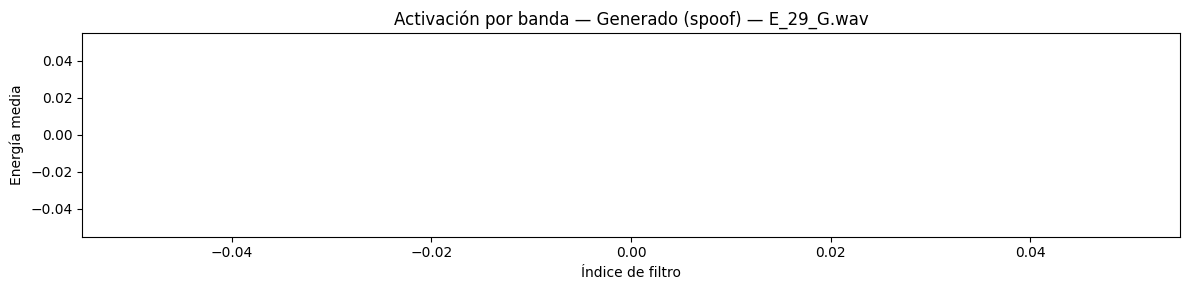


───────────────────────────────────────────────────────
  Audio: E_14_G.wav
  Real        : Generado (spoof)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


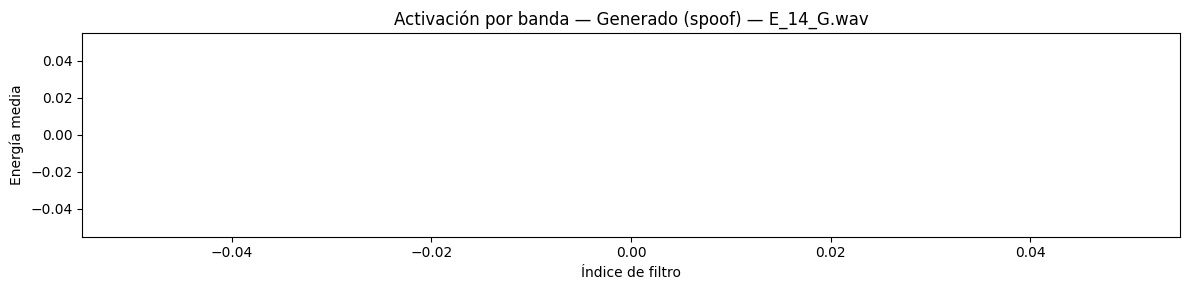


───────────────────────────────────────────────────────
  Audio: E_41_G.wav
  Real        : Generado (spoof)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


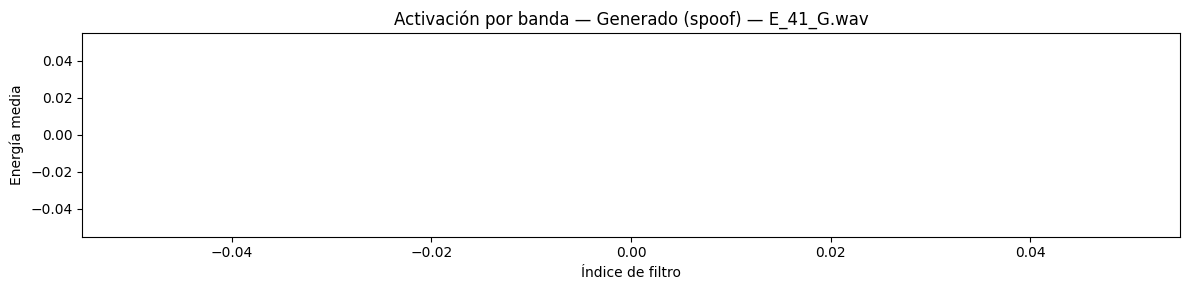


───────────────────────────────────────────────────────
  Audio: E_39_N.wav
  Real        : Natural (bonafide)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


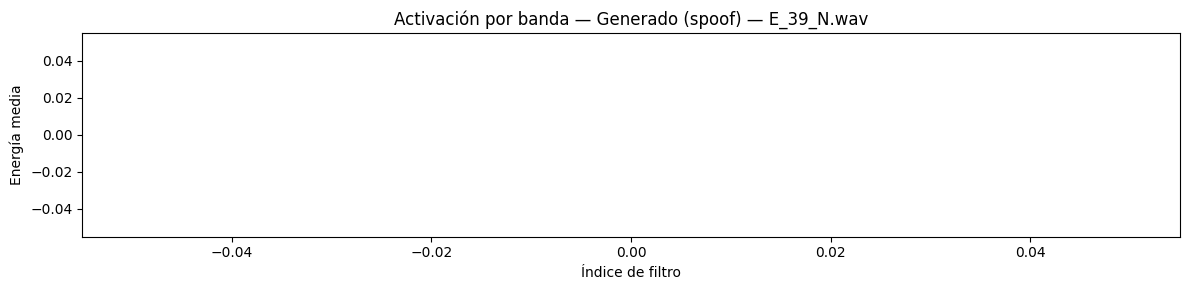


───────────────────────────────────────────────────────
  Audio: E_8_G.wav
  Real        : Generado (spoof)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


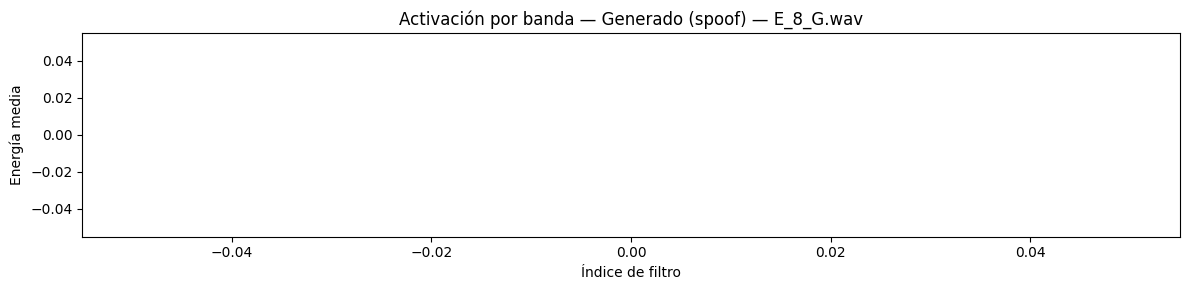


───────────────────────────────────────────────────────
  Audio: E_41_N.wav
  Real        : Natural (bonafide)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


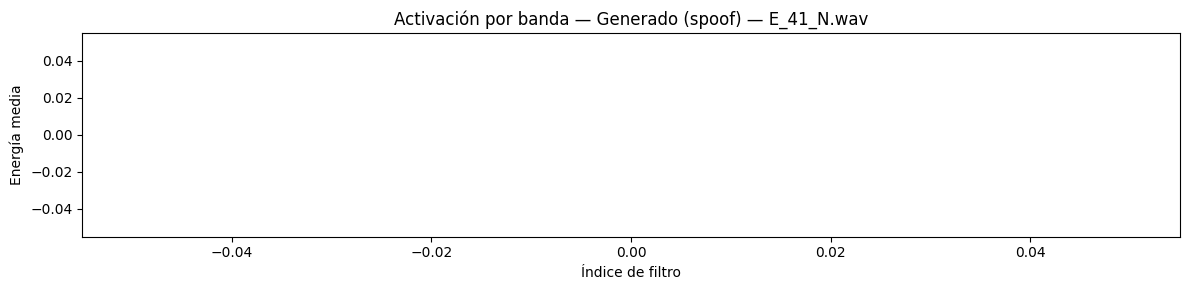


───────────────────────────────────────────────────────
  Audio: E_3_N.wav
  Real        : Natural (bonafide)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


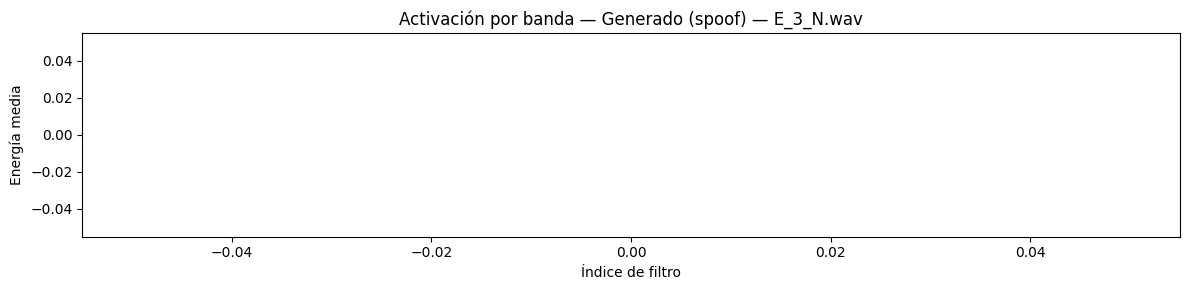


───────────────────────────────────────────────────────
  Audio: E_49_N.wav
  Real        : Natural (bonafide)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


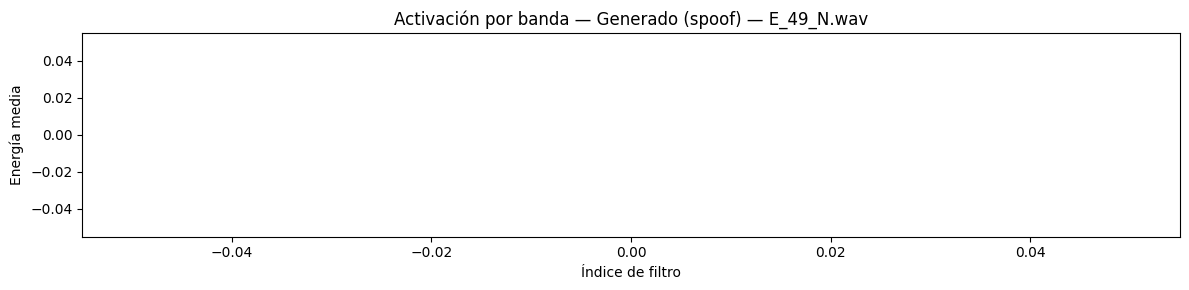


───────────────────────────────────────────────────────
  Audio: E_43_N.wav
  Real        : Natural (bonafide)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


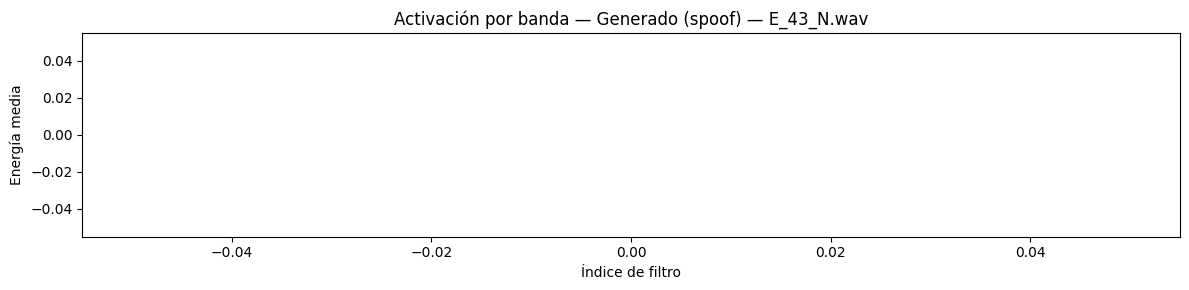


───────────────────────────────────────────────────────
  Audio: E_46_N.wav
  Real        : Natural (bonafide)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


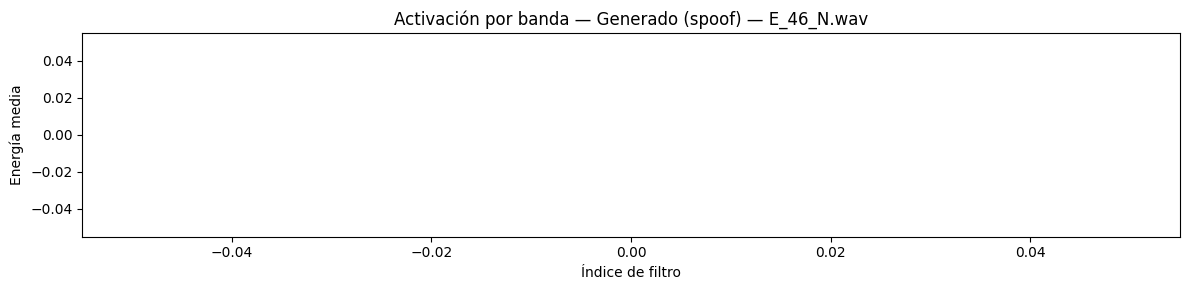


───────────────────────────────────────────────────────
  Audio: E_5_G.wav
  Real        : Generado (spoof)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


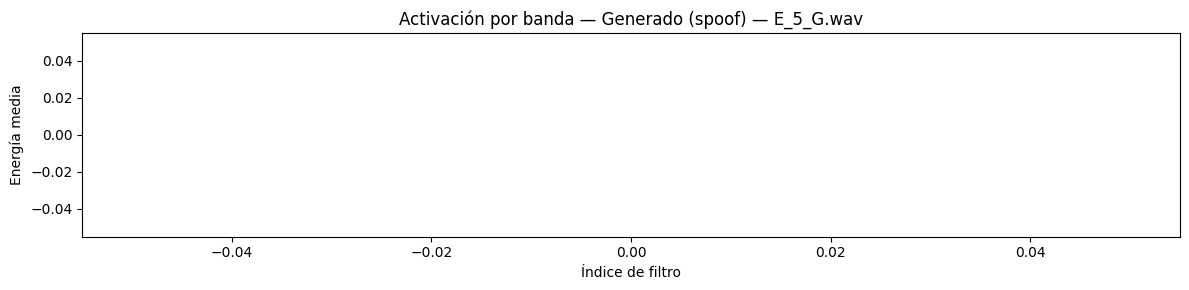


───────────────────────────────────────────────────────
  Audio: E_48_N.wav
  Real        : Natural (bonafide)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


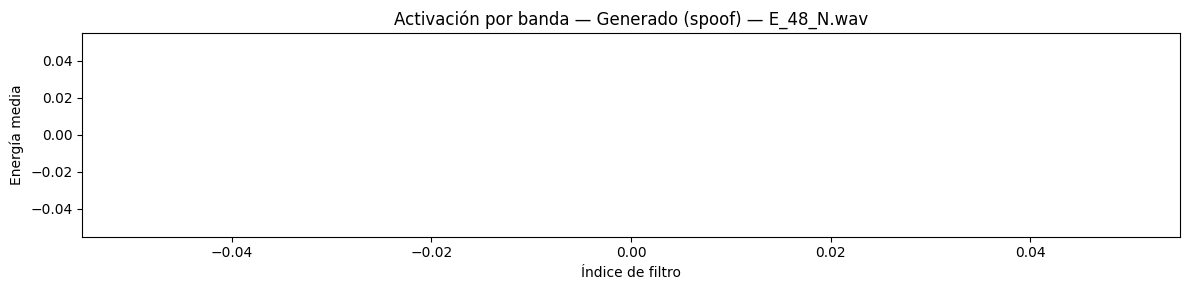


───────────────────────────────────────────────────────
  Audio: E_23_N.wav
  Real        : Natural (bonafide)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


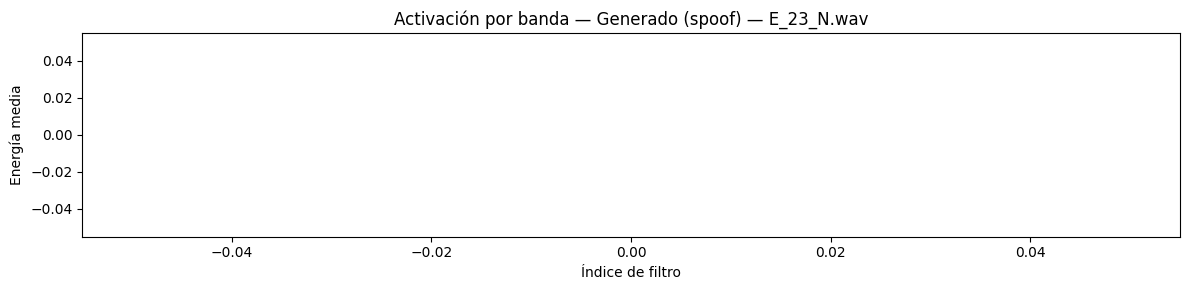


───────────────────────────────────────────────────────
  Audio: E_10_G.wav
  Real        : Generado (spoof)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


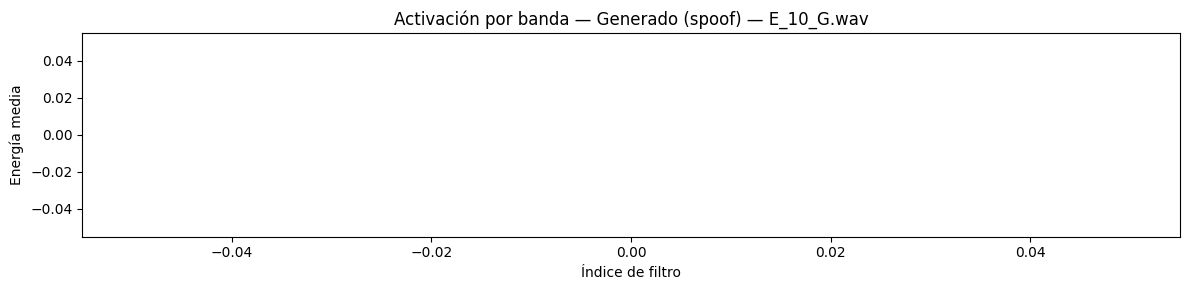


───────────────────────────────────────────────────────
  Audio: E_12_N.wav
  Real        : Natural (bonafide)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


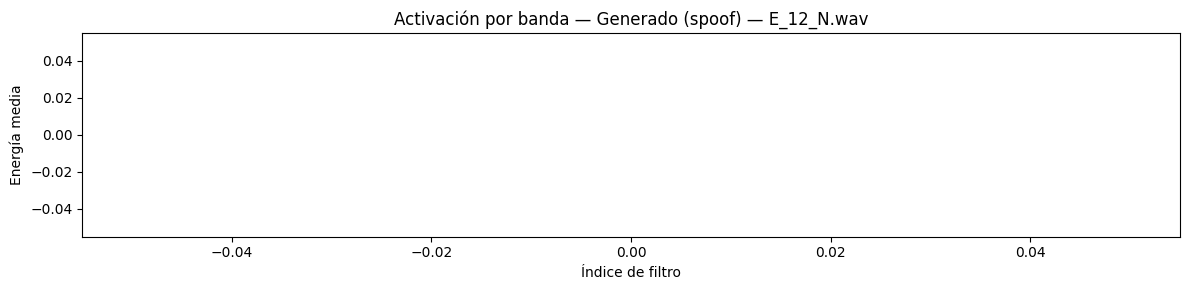


───────────────────────────────────────────────────────
  Audio: E_42_G.wav
  Real        : Generado (spoof)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


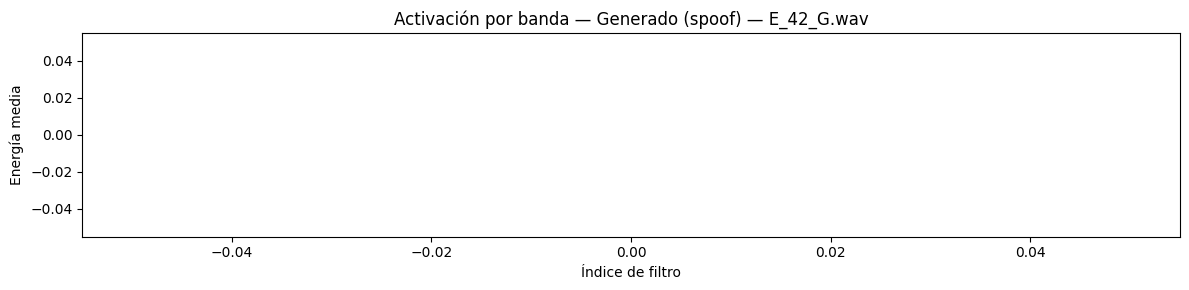


───────────────────────────────────────────────────────
  Audio: E_31_N.wav
  Real        : Natural (bonafide)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


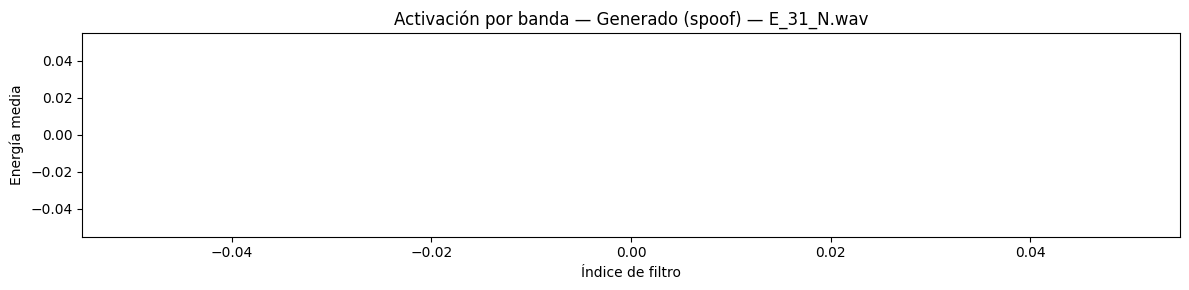


───────────────────────────────────────────────────────
  Audio: E_37_G.wav
  Real        : Generado (spoof)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


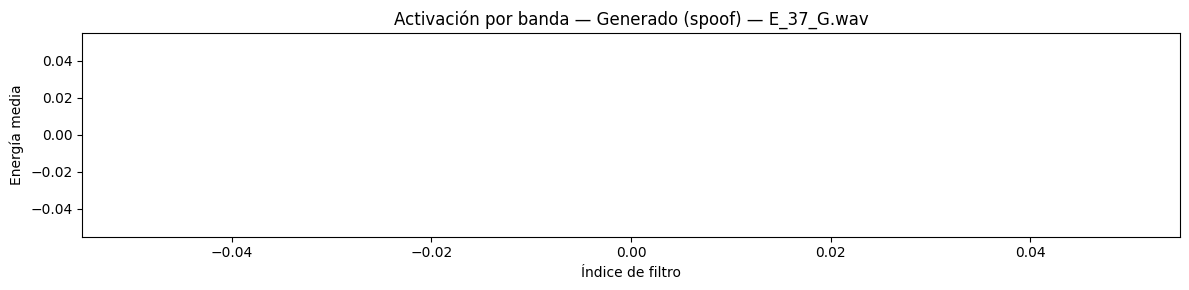


───────────────────────────────────────────────────────
  Audio: E_40_G.wav
  Real        : Generado (spoof)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


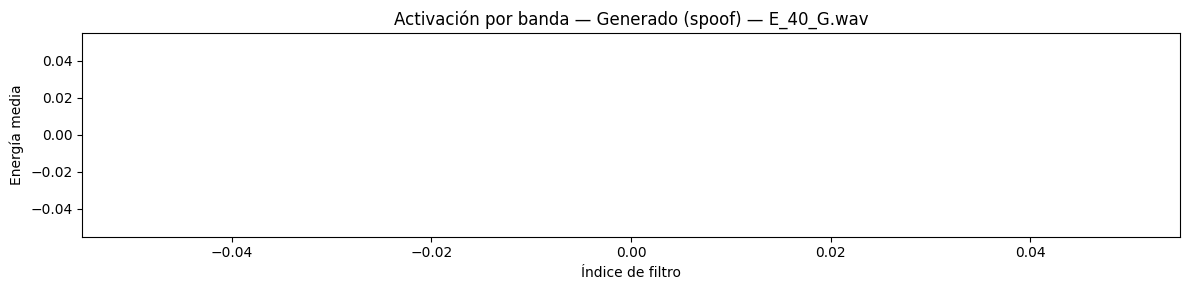


───────────────────────────────────────────────────────
  Audio: E_47_G.wav
  Real        : Generado (spoof)
  Predicción  : Generado (spoof)
  P(bonafide) : nan%  |  P(spoof): nan%
  Bandas más activas en esta decisión:
    Filtro #079: nan–7984 Hz  (energía: nan)
    Filtro #078: nan–nan Hz  (energía: nan)
    Filtro #021: nan–nan Hz  (energía: nan)
    Filtro #022: nan–nan Hz  (energía: nan)
    Filtro #023: nan–nan Hz  (energía: nan)


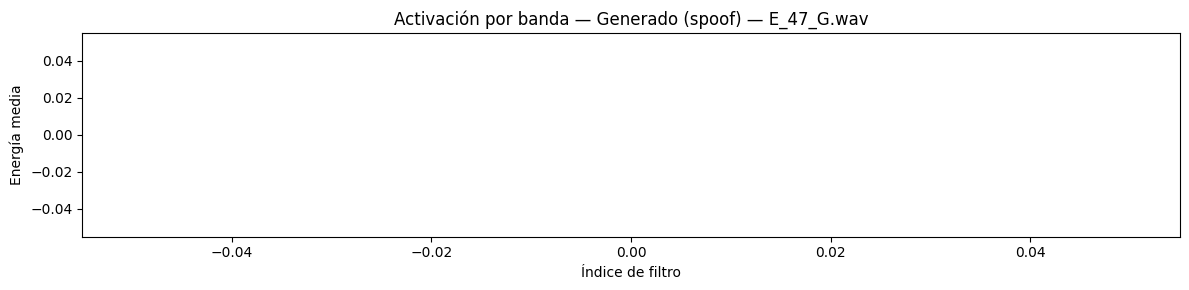

In [15]:
def explicar_sincnet(model, sample_rate=16000, top_k=10):
    """
    Explicación global: qué bandas frecuenciales aprendió el modelo.
    Los filtros con mayor ancho de banda son los más discriminativos.
    """
    model.eval()
    with torch.no_grad():
        f1 = torch.abs(model.sinc.f1).numpy()
        f2 = (torch.abs(model.sinc.f2) + 50).numpy()
        f2 = np.clip(f2, None, 0.499 * sample_rate)

    ancho_banda = f2 - f1
    orden       = np.argsort(ancho_banda)[::-1]

    print("\n" + "=" * 57)
    print("  EXPLICACIÓN GLOBAL — Filtros aprendidos por SincNet")
    print("=" * 57)
    print(f"  {'Filtro':>6} | {'F_low (Hz)':>10} | {'F_high (Hz)':>11} | {'Ancho (Hz)':>10}")
    print("-" * 57)
    for i in orden[:top_k]:
        print(f"  #{i:03d}   | {f1[i]:>10.1f} | {f2[i]:>11.1f} | {ancho_banda[i]:>10.1f}")
    print("=" * 57)

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # Gráfico 1: bandas como barras horizontales
    ax = axes[0]
    for i in range(len(f1)):
        ax.barh(i, f2[i] - f1[i], left=f1[i], height=0.8, alpha=0.5, color='steelblue')
    ax.axvline(300,  color='red',   linestyle='--', alpha=0.6, label='300 Hz')
    ax.axvline(3400, color='green', linestyle='--', alpha=0.6, label='3400 Hz')
    ax.set_xlabel("Frecuencia (Hz)")
    ax.set_ylabel("Índice de filtro")
    ax.set_title("Filtros aprendidos por SincNet — cada barra es una banda frecuencial")
    ax.legend()

    # Gráfico 2: histograma de frecuencias de corte
    ax2 = axes[1]
    ax2.hist(f1, bins=30, alpha=0.6, label='F_low',  color='steelblue')
    ax2.hist(f2, bins=30, alpha=0.6, label='F_high', color='orange')
    ax2.axvline(300,  color='red',   linestyle='--', alpha=0.6, label='300 Hz')
    ax2.axvline(3400, color='green', linestyle='--', alpha=0.6, label='3400 Hz')
    ax2.set_xlabel("Frecuencia (Hz)")
    ax2.set_ylabel("Número de filtros")
    ax2.set_title("Distribución de frecuencias de corte aprendidas")
    ax2.legend()

    plt.tight_layout()
    plt.savefig("sincnet_filtros_globales.png", dpi=150)
    plt.show()
    print("Gráfico guardado en sincnet_filtros_globales.png")


def explicar_muestra(model, waveform, sample_rate=16000, etiqueta_real=None, nombre=""):
    """
    Explicación local: qué bandas frecuenciales activaron más
    la decisión para un audio concreto.
    """
    model.eval()
    with torch.no_grad():
        x = waveform.unsqueeze(0)
        if x.dim() == 2:
            x = x.unsqueeze(1)                      # [1, 1, T]

        x_sinc   = model.sinc(x)                    # [1, out_channels, T]
        energias = torch.abs(x_sinc).mean(dim=2).squeeze().numpy()  # [out_channels]

        out  = model(waveform.unsqueeze(0))
        prob = torch.softmax(out, dim=1).squeeze()
        pred = out.argmax(dim=1).item()

        f1 = torch.abs(model.sinc.f1).numpy()
        f2 = (torch.abs(model.sinc.f2) + 50).numpy()
        f2 = np.clip(f2, None, 0.499 * sample_rate)

    top5_idx      = np.argsort(energias)[::-1][:5]
    etiqueta_pred = "Natural (bonafide)" if pred == 1 else "Generado (spoof)"

    print(f"\n{'─'*55}")
    if nombre:
        print(f"  Audio: {nombre}")
    if etiqueta_real is not None:
        etiqueta_real_str = "Natural (bonafide)" if etiqueta_real == 1 else "Generado (spoof)"
        print(f"  Real        : {etiqueta_real_str}")
    print(f"  Predicción  : {etiqueta_pred}")
    print(f"  P(bonafide) : {prob[1]:.2%}  |  P(spoof): {prob[0]:.2%}")
    print(f"  Bandas más activas en esta decisión:")
    for i in top5_idx:
        print(f"    Filtro #{i:03d}: {f1[i]:.0f}–{f2[i]:.0f} Hz  (energía: {energias[i]:.4f})")

    colores = ['tomato' if i in top5_idx else 'steelblue' for i in range(len(energias))]
    plt.figure(figsize=(12, 3))
    plt.bar(range(len(energias)), energias, color=colores)
    plt.xlabel("Índice de filtro")
    plt.ylabel("Energía media")
    plt.title(f"Activación por banda — {etiqueta_pred}{' — ' + nombre if nombre else ''}")
    plt.tight_layout()
    plt.show()

# ── Explicación global del modelo ─────────────────────────────────────────────
#explicar_sincnet(model, sample_rate=SAMPLE_RATE, top_k=10)

# ── Explicación de cada muestra de test ───────────────────────────────────────
for i in range(len(idx_test)):
    explicar_muestra(
        model,
        waveform     = X_test[i],
        sample_rate  = SAMPLE_RATE,
        etiqueta_real= y_test[i].item(),
        nombre       = os.path.basename(rutas[idx_test[i]])
    )